In [2]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [3]:
# Import packages
import torch
from Index_Generators.MultIndexSequenceGenerator import MultIndexSequenceGenerator
import matplotlib.pyplot as plt

In [4]:
# Build a multiple index sequence generator
batch_size = 1000
num_indices = 2
sequence_size = 9
h_size = 128
range_indices = [10, 8]
num_indices = 8
MyMISG = MultIndexSequenceGenerator(LSTM_hidden_size=h_size, FFNN_hidden_size=[h_size, h_size], num_categories=range_indices, FFNN_num_layers=[3, 5], sequence_size=sequence_size, batch_size=batch_size, weight = [None, None])

In [5]:
# Run the multiple index sequence generator
h0 = torch.randn(batch_size, h_size)
c0 = torch.randn(batch_size, h_size)
indices, total_logP, total_entropy, _, _ = MyMISG(h0, c0)
print(indices.shape)

torch.Size([1000, 2, 9])


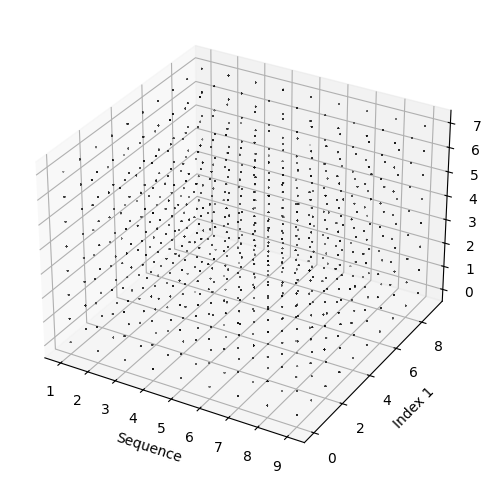

In [6]:
# Plot the results
x = torch.arange(1, sequence_size+1).detach()
y = indices[:,0,:].detach()
z = indices[:,1,:].detach()
sizes = torch.exp(total_logP.detach()) * 1000  

fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(1, 1, 1, projection='3d')
for i in range(batch_size):
    ax1.scatter(x, y[i,:], z[i,:], s=sizes[i], color='blue', alpha=0.1, edgecolors='black')
ax1.set_xlabel("Sequence")
ax1.set_ylabel("Index 1")
ax1.set_zlabel("Index 2")  
plt.show()